# Deep Learning Individual Project
## Student ID: s4139514

---

## Academic Honesty Statement

I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.


# 1. Introduction

## Problem Definition

This project addresses a **multiclass image classification** task using deep learning. We are provided with a custom dataset containing 16,000 grayscale images of size 32×32 pixels, distributed across 4 classes. The objective is to design, train, and evaluate a convolutional neural network (CNN) that can accurately classify these images.

## Dataset Overview

- **Total samples**: 16,000
- **Image dimensions**: 32×32 pixels
- **Channels**: Grayscale (single channel)
- **Classes**: 4 balanced classes (labels: 0, 1, 2, 3)
- **Data type**: Images are float32, labels are int64

## Learning Objectives

Following François Chollet's universal machine learning workflow (Chapters 5-6 of "Deep Learning with Python"), this project will:

1. **Establish a baseline**: Start with a simple CNN to understand the problem's difficulty
2. **Iterate and improve**: Systematically enhance the model using techniques like batch normalization, dropout, and regularization
3. **Conduct ablation studies**: Understand the impact of hyperparameters (optimizer, learning rate, regularization)
4. **Evaluate rigorously**: Use proper train/validation splits, avoid data leakage, and report comprehensive metrics
5. **Reflect and justify**: Explain every design decision with theoretical grounding

## Why CNNs?

Convolutional Neural Networks are the natural choice for image classification because:

- **Spatial structure**: CNNs exploit the 2D structure of images through convolutional operations
- **Translation invariance**: Convolutional filters detect features regardless of their position
- **Hierarchical features**: Early layers learn edges and textures; deeper layers learn complex patterns
- **Parameter efficiency**: Shared weights in convolutions reduce parameters compared to fully connected layers

This aligns with Chapter 8.1 of Chollet's book, which emphasizes that CNNs learn hierarchical feature representations automatically, eliminating the need for hand-engineered features.


In [3]:
# ============================================================================
# REPRODUCIBILITY SETUP
# ============================================================================
# Setting random seeds ensures reproducible results across runs
# This is critical for academic work and debugging
# ============================================================================
import numpy as np
import tensorflow as tf
import random
import os

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Print versions for reproducibility
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Random seed set to:", SEED)


/Users/baonguyen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.17.1
NumPy version: 1.26.4
Random seed set to: 42


In [4]:
# ============================================================================
# DATASET LOADING
# ============================================================================
# Load the dataset from 4class_32x32.npz
# X: (16000, 32, 32) float32 - grayscale images
# y: (16000,) int64 - class labels in {0, 1, 2, 3}
# ============================================================================
data = np.load("4class_32x32.npz")
X = data["X"]
y = data["y"]

print("Dataset loaded successfully!")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")
print(f"X value range: [{X.min():.6f}, {X.max():.6f}]")
print(f"Unique labels: {np.unique(y)}")
print(f"Number of classes: {len(np.unique(y))}")


Dataset loaded successfully!
X shape: (16000, 32, 32), dtype: float32
y shape: (16000,), dtype: int64
X value range: [0.000000, 5.069554]
Unique labels: [0 1 2 3]
Number of classes: 4


# 2. Dataset Inspection

Let us explore the dataset to understand its characteristics, distribution, and visual properties.


Class distribution:
  Class 0: 4000 samples (25.0%)
  Class 1: 4000 samples (25.0%)
  Class 2: 4000 samples (25.0%)
  Class 3: 4000 samples (25.0%)


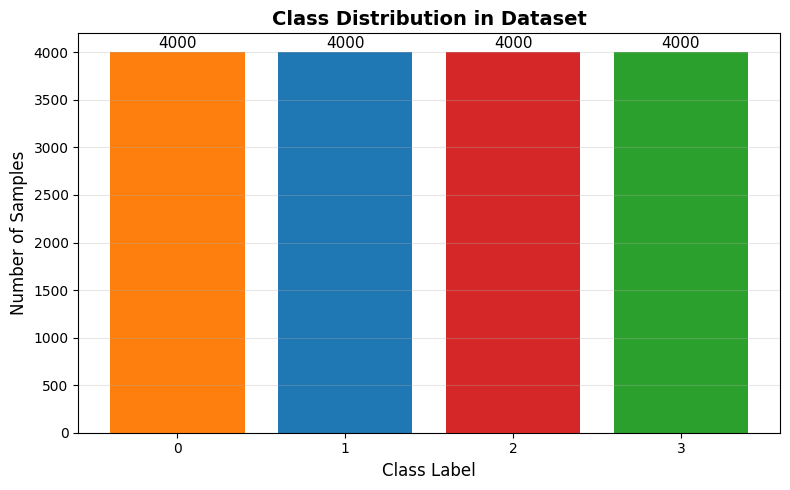


Dataset is balanced
✓ All classes have equal representation - stratified split is appropriate


In [6]:
# ============================================================================
# CLASS DISTRIBUTION ANALYSIS
# ============================================================================
# Understanding class balance is crucial for:
# - Choosing appropriate evaluation metrics
# - Deciding on stratified splits
# - Identifying potential class imbalance issues
# ============================================================================
import matplotlib.pyplot as plt
from collections import Counter

class_counts = Counter(y)
print("Class distribution:")
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    percentage = (count / len(y)) * 100
    print(f"  Class {class_id}: {count} samples ({percentage:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2, 3])
plt.grid(axis='y', alpha=0.3)
for i, (class_id, count) in enumerate(sorted(class_counts.items())):
    plt.text(class_id, count + 50, str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# Check if balanced
is_balanced = len(set(class_counts.values())) == 1
print(f"\nDataset is {'balanced' if is_balanced else 'imbalanced'}")
if is_balanced:
    print("✓ All classes have equal representation - stratified split is appropriate")


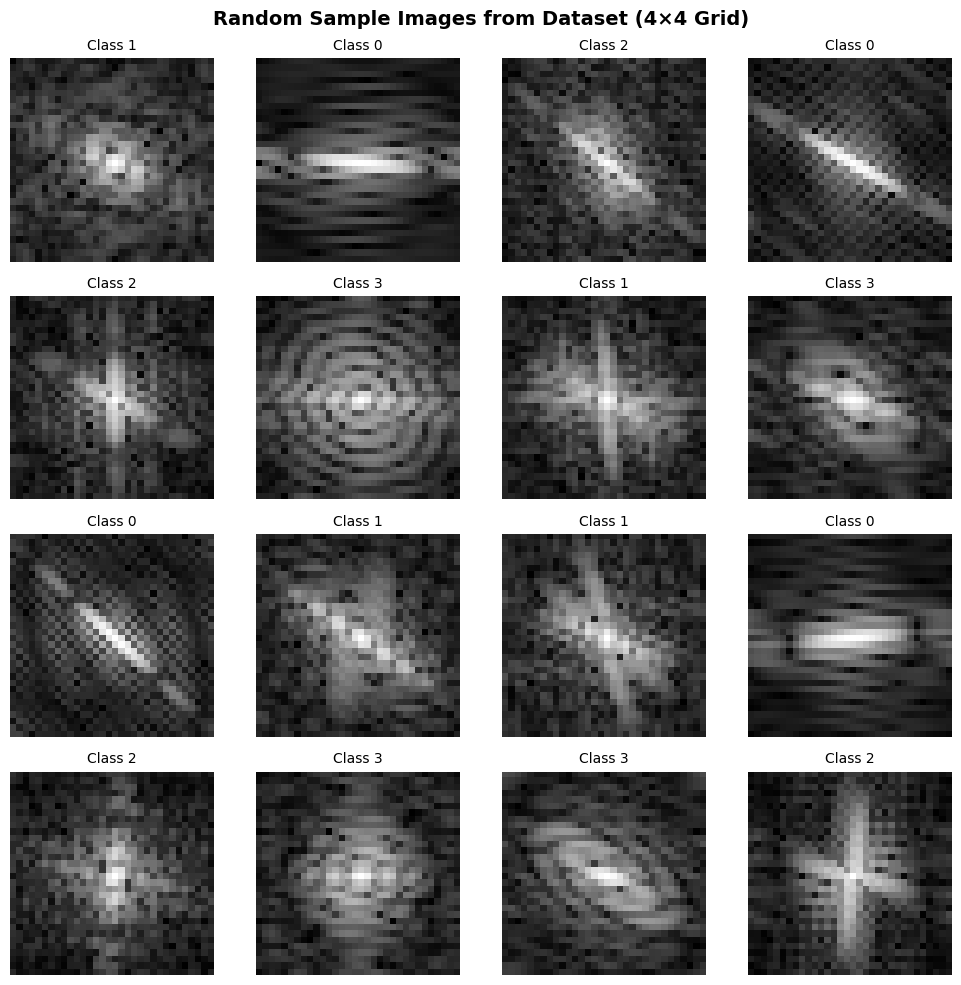

Visual observations:
- Images are 32×32 grayscale
- Classes appear visually distinct (to be confirmed by model performance)
- Using 'nearest' interpolation preserves pixel boundaries (no smoothing)


In [7]:
# ============================================================================
# VISUALIZE RANDOM SAMPLE GRID (4×4)
# ============================================================================
# Displaying random samples helps us understand:
# - Visual patterns in the data
# - Differences between classes
# - Noise levels and image quality
# - Potential classification difficulty
# ============================================================================
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Random Sample Images from Dataset (4×4 Grid)', fontsize=14, fontweight='bold')

# Select 16 random indices (4 per class to ensure representation)
indices_per_class = []
for class_id in range(4):
    class_indices = np.where(y == class_id)[0]
    selected = np.random.choice(class_indices, size=4, replace=False)
    indices_per_class.extend(selected)

np.random.shuffle(indices_per_class)
selected_indices = indices_per_class[:16]

for idx, ax in enumerate(axes.flat):
    sample_idx = selected_indices[idx]
    image = X[sample_idx]
    label = y[sample_idx]
    
    ax.imshow(image, cmap='gray', interpolation='nearest')
    ax.set_title(f'Class {label}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Visual observations:")
print("- Images are 32×32 grayscale")
print("- Classes appear visually distinct (to be confirmed by model performance)")
print("- Using 'nearest' interpolation preserves pixel boundaries (no smoothing)")


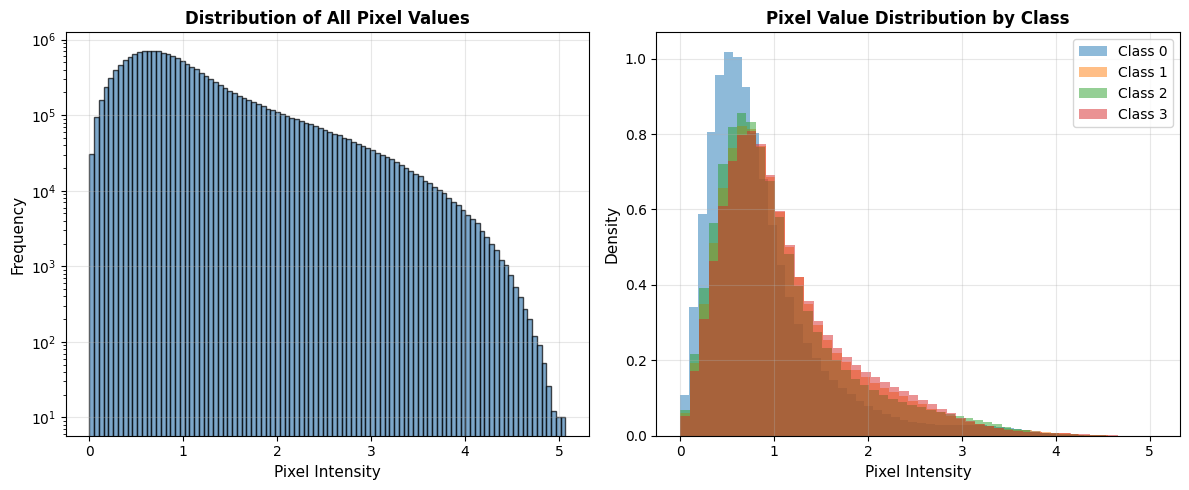

Pixel value statistics:
  Mean: 1.0383
  Std: 0.7011
  Min: 0.000000
  Max: 5.069554

Note: Values are not in [0,1] range, so standardization will be beneficial.


In [8]:
# ============================================================================
# PIXEL INTENSITY HISTOGRAM
# ============================================================================
# Understanding the distribution of pixel values helps us:
# - Determine appropriate normalization/standardization
# - Identify if data is already normalized
# - Understand dynamic range
# ============================================================================
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of all pixel values
plt.subplot(1, 2, 1)
plt.hist(X.flatten(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Pixel Intensity', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of All Pixel Values', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.yscale('log')  # Log scale for better visualization

# Plot 2: Per-class pixel value distributions
plt.subplot(1, 2, 2)
for class_id in range(4):
    class_mask = (y == class_id)
    class_pixels = X[class_mask].flatten()
    plt.hist(class_pixels, bins=50, alpha=0.5, label=f'Class {class_id}', density=True)
plt.xlabel('Pixel Intensity', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Pixel Value Distribution by Class', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pixel value statistics:")
print(f"  Mean: {X.mean():.4f}")
print(f"  Std: {X.std():.4f}")
print(f"  Min: {X.min():.6f}")
print(f"  Max: {X.max():.6f}")
print(f"\nNote: Values are not in [0,1] range, so standardization will be beneficial.")


# 3. Train/Validation Split

Following Chollet's universal workflow (Chapter 5), we must split our data into training and validation sets **before any preprocessing**. This prevents data leakage, where information from the validation set inadvertently influences training decisions.

## Split Strategy

- **Stratified split**: Ensures each class is represented proportionally in both sets
- **80/20 split**: Common practice that provides sufficient training data while maintaining a robust validation set
- **Justification**: 
  - With 16,000 samples, an 80/20 split gives us 12,800 training and 3,200 validation samples
  - This is sufficient for training deep models while having enough validation data for reliable evaluation
  - Stratification ensures we don't accidentally create an imbalanced split


In [10]:
# ============================================================================
# TRAIN/VALIDATION SPLIT (STRATIFIED)
# ============================================================================
# Using sklearn's train_test_split with stratification ensures:
# - Proportional class representation in both sets
# - Reproducible splits (with random_state)
# - No data leakage (split happens before preprocessing)
# ============================================================================
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y  # Ensures balanced class distribution
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Split ratio: {X_train.shape[0] / len(X):.1%} train, {X_val.shape[0] / len(X):.1%} validation")

# Verify stratification
print("\nClass distribution in training set:")
train_counts = Counter(y_train)
for class_id in sorted(train_counts.keys()):
    count = train_counts[class_id]
    percentage = (count / len(y_train)) * 100
    print(f"  Class {class_id}: {count} samples ({percentage:.1f}%)")

print("\nClass distribution in validation set:")
val_counts = Counter(y_val)
for class_id in sorted(val_counts.keys()):
    count = val_counts[class_id]
    percentage = (count / len(y_val)) * 100
    print(f"  Class {class_id}: {count} samples ({percentage:.1f}%)")


Training set: 12800 samples
Validation set: 3200 samples
Split ratio: 80.0% train, 20.0% validation

Class distribution in training set:
  Class 0: 3200 samples (25.0%)
  Class 1: 3200 samples (25.0%)
  Class 2: 3200 samples (25.0%)
  Class 3: 3200 samples (25.0%)

Class distribution in validation set:
  Class 0: 800 samples (25.0%)
  Class 1: 800 samples (25.0%)
  Class 2: 800 samples (25.0%)
  Class 3: 800 samples (25.0%)


# 4. Preprocessing

Preprocessing is critical for neural network training. We apply two key transformations:

1. **Reshaping**: Convert from (N, 32, 32) to (N, 32, 32, 1) to add the channel dimension required by Keras CNNs
2. **Standardization**: Normalize pixel values to have zero mean and unit variance using **training set statistics only**

## Why Standardization?

- Neural networks train faster and more stably when inputs are centered around zero
- Prevents gradient issues from large input values
- Helps with weight initialization effectiveness

## Critical: Training-Only Statistics

We compute mean and standard deviation from the **training set only**, then apply these same statistics to the validation set. Using validation/test statistics would be data leakage, as it gives the model information about the validation set during training.


In [12]:
# ============================================================================
# PREPROCESSING: RESHAPING AND STANDARDIZATION
# ============================================================================
# Step 1: Reshape to add channel dimension (N, 32, 32) -> (N, 32, 32, 1)
# Step 2: Standardize using training set statistics only
# Formula: x' = (x - μ_train) / σ_train
# ============================================================================

# Reshape: Add channel dimension for Keras CNN input
X_train_reshaped = X_train.reshape(X_train.shape[0], 32, 32, 1)
X_val_reshaped = X_val.reshape(X_val.shape[0], 32, 32, 1)

print(f"After reshaping:")
print(f"  X_train: {X_train_reshaped.shape}")
print(f"  X_val: {X_val_reshaped.shape}")

# Compute statistics from TRAINING SET ONLY (critical to avoid data leakage)
train_mean = X_train_reshaped.mean()
train_std = X_train_reshaped.std()

print(f"\nTraining set statistics:")
print(f"  Mean: {train_mean:.6f}")
print(f"  Std: {train_std:.6f}")

# Standardize both sets using training statistics
X_train_processed = (X_train_reshaped - train_mean) / train_std
X_val_processed = (X_val_reshaped - train_mean) / train_std

print(f"\nAfter standardization:")
print(f"  X_train mean: {X_train_processed.mean():.6f} (should be ~0)")
print(f"  X_train std: {X_train_processed.std():.6f} (should be ~1)")
print(f"  X_val mean: {X_val_processed.mean():.6f}")
print(f"  X_val std: {X_val_processed.std():.6f}")

# Store for later use
X_train_final = X_train_processed
X_val_final = X_val_processed


After reshaping:
  X_train: (12800, 32, 32, 1)
  X_val: (3200, 32, 32, 1)

Training set statistics:
  Mean: 1.038013
  Std: 0.701081

After standardization:
  X_train mean: -0.000001 (should be ~0)
  X_train std: 0.999999 (should be ~1)
  X_val mean: 0.001815
  X_val std: 1.000263


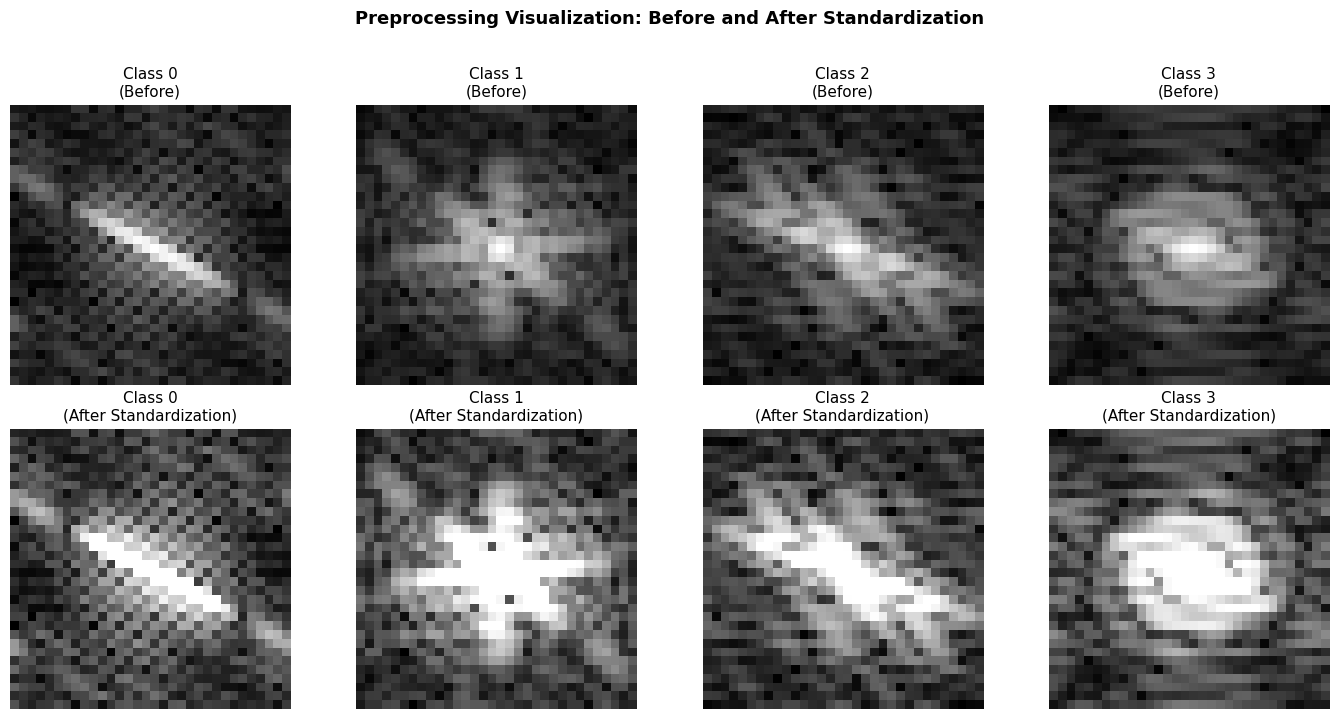

Note: Standardized images are centered around zero with unit variance.
This helps CNNs learn more effectively by normalizing the input distribution.


In [13]:
# ============================================================================
# VISUALIZE PREPROCESSING EFFECT
# ============================================================================
# Show before/after preprocessing to understand the transformation
# ============================================================================
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Select one sample from each class
for class_id in range(4):
    class_indices = np.where(y_train == class_id)[0]
    sample_idx = class_indices[0]
    
    # Before preprocessing (original)
    axes[0, class_id].imshow(X_train[sample_idx], cmap='gray', interpolation='nearest')
    axes[0, class_id].set_title(f'Class {class_id}\n(Before)', fontsize=11)
    axes[0, class_id].axis('off')
    
    # After preprocessing (standardized)
    # Note: Standardized images may have negative values, so we clip for display
    processed_display = np.clip(X_train_final[sample_idx, :, :, 0], -2, 2)
    axes[1, class_id].imshow(processed_display, cmap='gray', interpolation='nearest')
    axes[1, class_id].set_title(f'Class {class_id}\n(After Standardization)', fontsize=11)
    axes[1, class_id].axis('off')

plt.suptitle('Preprocessing Visualization: Before and After Standardization', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Note: Standardized images are centered around zero with unit variance.")
print("This helps CNNs learn more effectively by normalizing the input distribution.")


# 5. Baseline Model

We start with a simple CNN architecture to establish a baseline. This follows Chollet's principle of starting simple and iterating.

## Architecture Rationale

- **Convolutional layers**: Extract spatial features (edges, textures, patterns)
- **ReLU activation**: Introduces non-linearity, helps with gradient flow
- **MaxPooling**: Reduces spatial dimensions, increases receptive field, provides translation invariance
- **Flatten**: Converts 2D feature maps to 1D for dense layers
- **Dense layers**: Learn high-level feature combinations
- **Softmax output**: Produces probability distribution over 4 classes
- **Sparse Categorical Crossentropy**: Appropriate for integer-encoded labels (0, 1, 2, 3)


In [15]:
# ============================================================================
# BASELINE MODEL DEFINITION
# ============================================================================
# Simple CNN architecture:
# - Conv2D(32 filters) -> ReLU -> MaxPooling
# - Conv2D(64 filters) -> ReLU -> MaxPooling  
# - Flatten
# - Dense(128) -> ReLU
# - Dense(4) -> Softmax
# ============================================================================
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_model():
    """Build a simple baseline CNN model."""
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
        layers.MaxPooling2D((2, 2)),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        
        # Output layer: 4 classes with softmax
        layers.Dense(4, activation='softmax')
    ])
    
    return model

# Build and compile baseline model
baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
baseline_model.summary()

# Count parameters
total_params = baseline_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")


/Users/baonguyen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,372 (1.20 MB)

 Trainable params: 314,372 (1.20 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 314,372


In [16]:
# ============================================================================
# TRAIN BASELINE MODEL
# ============================================================================
# Training with:
# - Early stopping to prevent overfitting
# - Validation monitoring
# - Batch size: 32 (good balance between speed and stability)
# ============================================================================
from tensorflow.keras.callbacks import EarlyStopping

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train baseline model
print("Training baseline model...")
baseline_history = baseline_model.fit(
    X_train_final, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_final, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("\nBaseline training completed!")


Training baseline model...
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7360 - loss: 0.6237 - val_accuracy: 0.9259 - val_loss: 0.2108
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9488 - loss: 0.1437 - val_accuracy: 0.9575 - val_loss: 0.1270
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9709 - loss: 0.0901 - val_accuracy: 0.9594 - val_loss: 0.1192
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9803 - loss: 0.0610 - val_accuracy: 0.9678 - val_loss: 0.0928
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9878 - loss: 0.0419 - val_accuracy: 0.9766 - val_loss: 0.0831
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9892 - loss: 0.0305 - val_accuracy: 0.9741 - val_loss: 0.0868
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9933 - loss: 0.0222 - val_accuracy: 0.9737 - val_loss: 0.0917
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9940 - loss

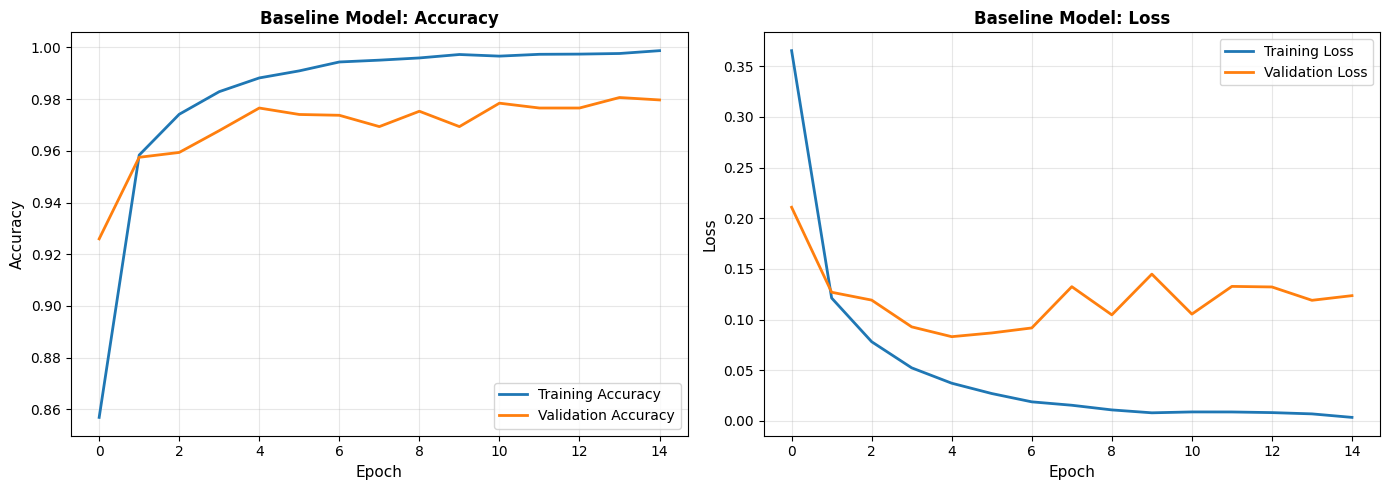

Baseline Model - Final Metrics:
  Training Accuracy: 0.9987 (99.87%)
  Validation Accuracy: 0.9797 (97.97%)
  Training Loss: 0.0035
  Validation Loss: 0.1236

✓ Model shows good generalization (gap: 0.0191)


In [17]:
# ============================================================================
# PLOT BASELINE TRAINING CURVES
# ============================================================================
# Visualize training history to understand model behavior:
# - Accuracy: How well the model classifies
# - Loss: How well the model minimizes the loss function
# - Gap between train/val: Indicates overfitting
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(baseline_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Baseline Model: Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(baseline_history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(baseline_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Baseline Model: Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = baseline_history.history['accuracy'][-1]
final_val_acc = baseline_history.history['val_accuracy'][-1]
final_train_loss = baseline_history.history['loss'][-1]
final_val_loss = baseline_history.history['val_loss'][-1]

print("Baseline Model - Final Metrics:")
print(f"  Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")

# Check for overfitting
overfitting_gap = final_train_acc - final_val_acc
if overfitting_gap > 0.05:
    print(f"\n⚠️  Potential overfitting detected (gap: {overfitting_gap:.4f})")
    print("   Consider adding regularization in improved model.")
else:
    print(f"\n✓ Model shows good generalization (gap: {overfitting_gap:.4f})")


# 6. Improved Model

Based on the baseline performance, we now build an improved model incorporating several techniques:

1. **Batch Normalization**: Normalizes layer inputs, stabilizes training, allows higher learning rates
2. **Dropout**: Regularization technique that prevents overfitting by randomly setting neurons to zero
3. **Additional Convolutional Layers**: Deeper network can learn more complex features
4. **Learning Rate Scheduling**: Adaptive learning rate reduction for better convergence

These improvements follow best practices from Chapters 5-6 of Chollet's book.


In [19]:
# ============================================================================
# IMPROVED MODEL DEFINITION
# ============================================================================
# Enhanced architecture with:
# - Batch Normalization after each conv/dense layer
# - Dropout for regularization
# - Deeper convolutional layers
# - More filters to capture complex patterns
# ============================================================================
def build_improved_model():
    """Build an improved CNN model with BatchNorm, Dropout, and deeper layers."""
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), input_shape=(32, 32, 1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third convolutional block (additional depth)
        layers.Conv2D(128, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten
        layers.Flatten(),
        
        # Dense layers with BatchNorm and Dropout
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(4, activation='softmax')
    ])
    
    return model

# Build improved model
improved_model = build_improved_model()
improved_model.compile(
    optimizer='adam',  # Adam optimizer for adaptive learning rates
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
improved_model.summary()

# Count parameters
total_params = improved_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,948 (886.52 KB)

 Trainable params: 225,988 (882.77 KB)

 Non-trainable params: 960 (3.75 KB)


Total trainable parameters: 226,948


In [20]:
# ============================================================================
# TRAIN IMPROVED MODEL WITH CALLBACKS
# ============================================================================
# Callbacks:
# - EarlyStopping: Stop when validation loss stops improving
# - ReduceLROnPlateau: Reduce learning rate when stuck
# ============================================================================
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Enhanced callbacks
early_stopping_improved = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train improved model
print("Training improved model...")
improved_history = improved_model.fit(
    X_train_final, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_final, y_val),
    callbacks=[early_stopping_improved, reduce_lr],
    verbose=1
)

print("\nImproved model training completed!")


Training improved model...
Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6807 - loss: 0.7987 - val_accuracy: 0.9147 - val_loss: 0.2491 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9029 - loss: 0.2681 - val_accuracy: 0.9481 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9144 - loss: 0.2331 - val_accuracy: 0.9541 - val_loss: 0.1320 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9294 - loss: 0.2001 - val_accuracy: 0.9584 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9411 - loss: 0.1668 - val_accuracy: 0.9625 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9425 - loss: 0.1578 - val_accuracy: 0.9684 - val_loss: 0.0923 - learning_rate: 0.0010
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/

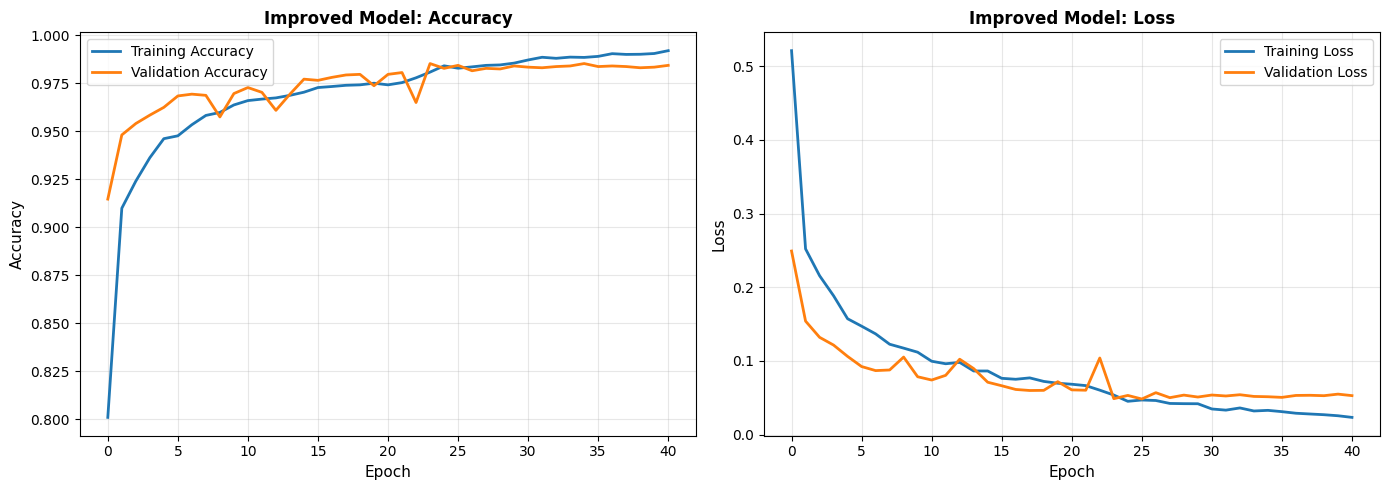

Improved Model - Final Metrics:
  Training Accuracy: 0.9920 (99.20%)
  Validation Accuracy: 0.9844 (98.44%)
  Training Loss: 0.0233
  Validation Loss: 0.0529

Improvement over baseline: 0.0038 (0.38 percentage points)


In [21]:
# ============================================================================
# PLOT IMPROVED MODEL TRAINING CURVES
# ============================================================================
# Compare improved model performance with baseline
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(improved_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(improved_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Improved Model: Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(improved_history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(improved_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Improved Model: Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = improved_history.history['accuracy'][-1]
final_val_acc = improved_history.history['val_accuracy'][-1]
final_train_loss = improved_history.history['loss'][-1]
final_val_loss = improved_history.history['val_loss'][-1]

print("Improved Model - Final Metrics:")
print(f"  Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")

# Compare with baseline
baseline_val_acc = max(baseline_history.history['val_accuracy'])
improvement = final_val_acc - baseline_val_acc
print(f"\nImprovement over baseline: {improvement:.4f} ({improvement*100:.2f} percentage points)")


# 7. Evaluation Metrics

Comprehensive evaluation is essential to understand model performance beyond simple accuracy. We compute:

- **Confusion Matrix**: Shows which classes are confused with each other
- **Per-Class Metrics**: Precision, Recall, and F1-score for each class
- **Overall Accuracy**: Overall classification performance


In [23]:
# ============================================================================
# EVALUATE IMPROVED MODEL ON VALIDATION SET
# ============================================================================
# Generate predictions and compute comprehensive metrics
# ============================================================================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Get predictions
y_val_pred_proba = improved_model.predict(X_val_final, verbose=0)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Overall accuracy
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix (Absolute):")
print(cm)

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("\nConfusion Matrix (Normalized):")
print(cm_normalized)


Validation Accuracy: 0.9844 (98.44%)

Confusion Matrix (Absolute):
[[789   2   9   0]
 [  2 790   3   5]
 [  2   8 784   6]
 [  4   4   5 787]]

Confusion Matrix (Normalized):
[[0.98625 0.0025  0.01125 0.     ]
 [0.0025  0.9875  0.00375 0.00625]
 [0.0025  0.01    0.98    0.0075 ]
 [0.005   0.005   0.00625 0.98375]]


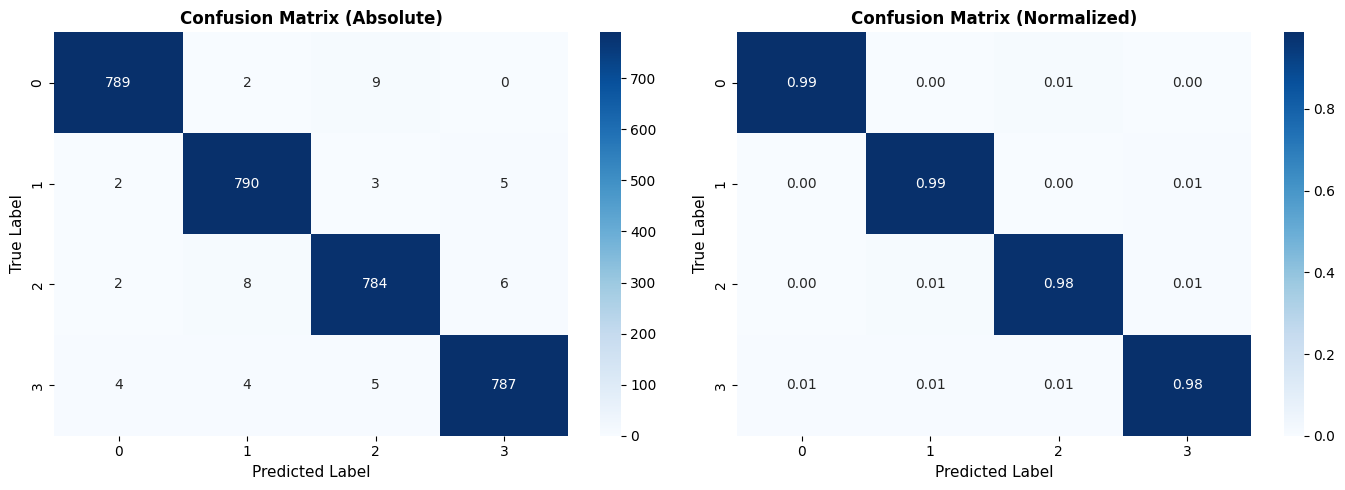

Confusion Matrix Analysis:
  Class 0: 789/800 correct (98.62%)
  Class 1: 790/800 correct (98.75%)
  Class 2: 784/800 correct (98.00%)
  Class 3: 787/800 correct (98.38%)


In [24]:
# ============================================================================
# VISUALIZE CONFUSION MATRIX
# ============================================================================
# Heatmap visualization helps identify misclassification patterns
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Absolute)', fontsize=12, fontweight='bold')

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis
print("Confusion Matrix Analysis:")
for i in range(4):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy_per_class = correct / total
    print(f"  Class {i}: {correct}/{total} correct ({accuracy_per_class:.2%})")


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99       800
     Class 1       0.98      0.99      0.99       800
     Class 2       0.98      0.98      0.98       800
     Class 3       0.99      0.98      0.98       800

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



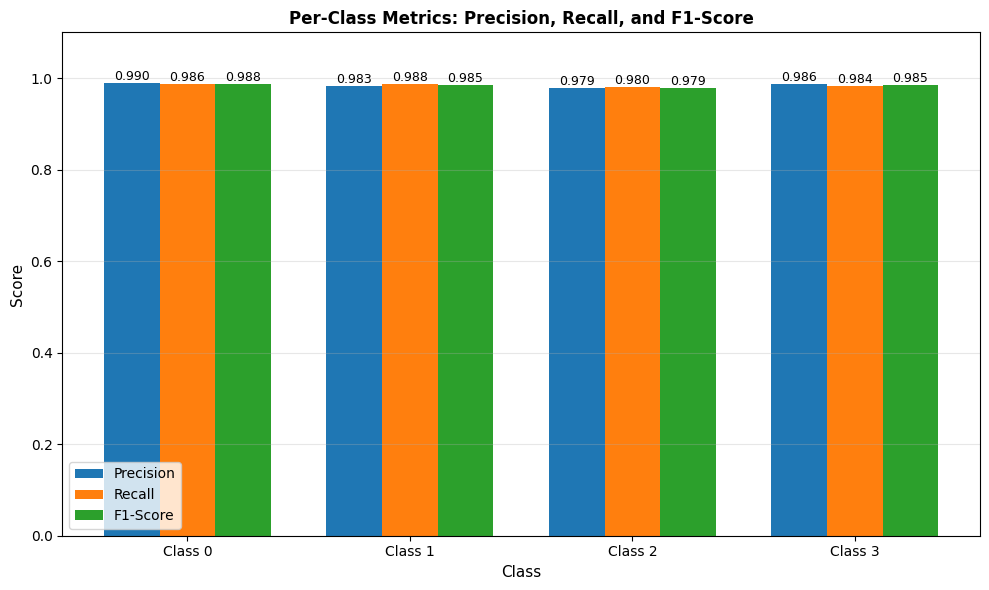


Interpretation:
- Precision: Of all predictions for a class, how many were correct?
- Recall: Of all true instances of a class, how many were found?
- F1-Score: Harmonic mean of precision and recall (balanced metric)


In [25]:
# ============================================================================
# PER-CLASS METRICS: PRECISION, RECALL, F1-SCORE
# ============================================================================
# Detailed classification report
# ============================================================================
report = classification_report(y_val, y_val_pred, target_names=[f'Class {i}' for i in range(4)])
print("Classification Report:")
print(report)

# Extract per-class metrics for visualization
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_val, y_val_pred, labels=[0, 1, 2, 3])

# Visualize per-class metrics
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
bars2 = ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ca02c')

ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Class Metrics: Precision, Recall, and F1-Score', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Class {i}' for i in range(4)])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Precision: Of all predictions for a class, how many were correct?")
print("- Recall: Of all true instances of a class, how many were found?")
print("- F1-Score: Harmonic mean of precision and recall (balanced metric)")


Total misclassified samples: 50 out of 3200
Accuracy: 98.44%


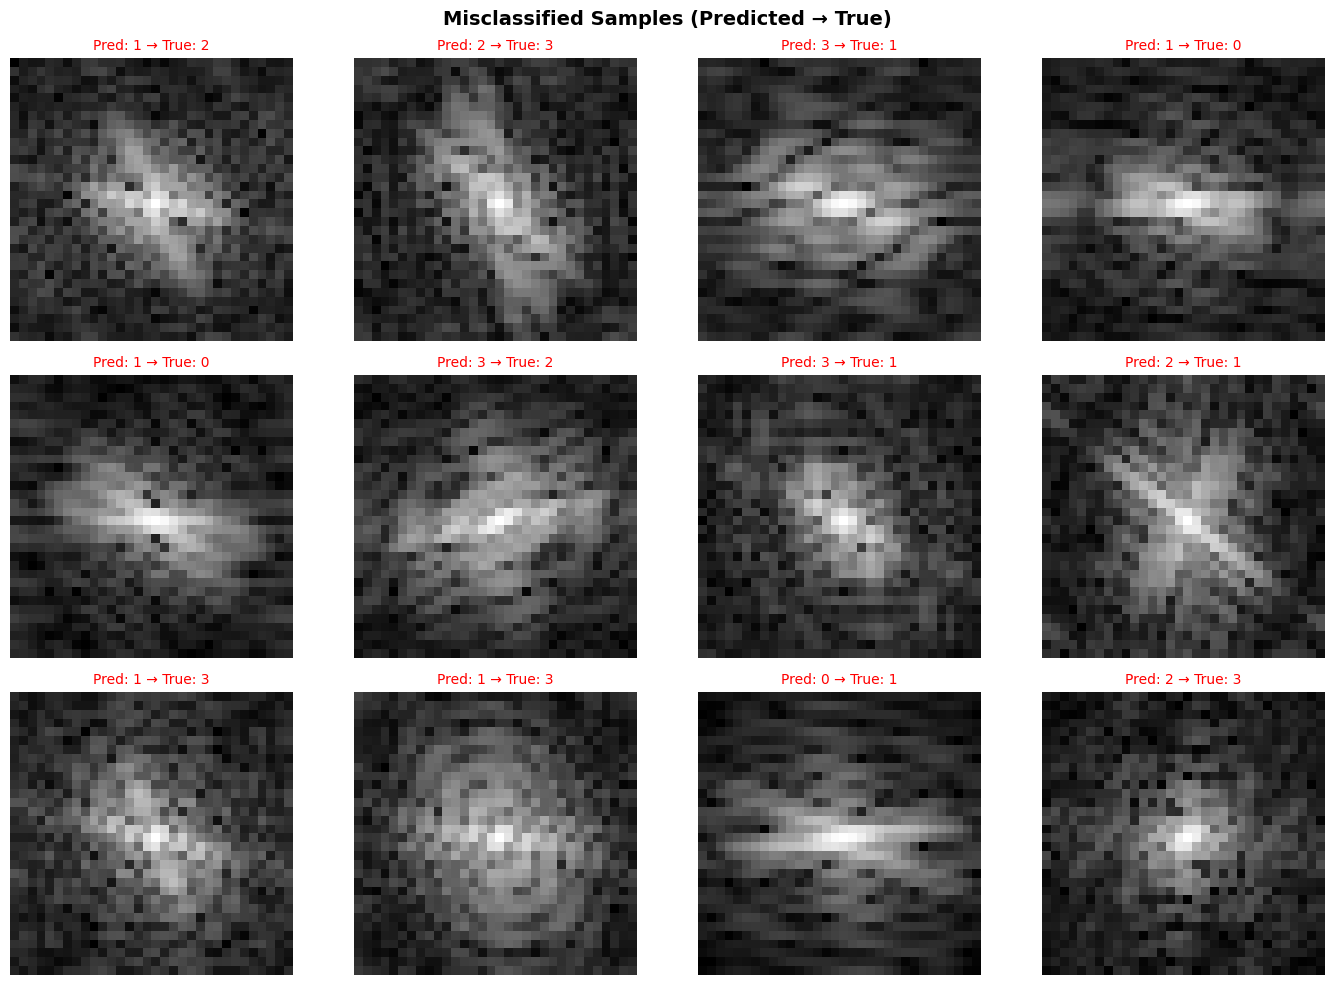


Observations:
- Misclassifications may indicate:
  * Visual similarity between classes
  * Noise or ambiguous patterns
  * Need for data augmentation or more training data


In [26]:
# ============================================================================
# VISUALIZE MISCLASSIFIED SAMPLES
# ============================================================================
# Understanding what the model gets wrong helps identify improvement areas
# ============================================================================
# Find misclassified samples
misclassified_indices = np.where(y_val != y_val_pred)[0]

print(f"Total misclassified samples: {len(misclassified_indices)} out of {len(y_val)}")
print(f"Accuracy: {(len(y_val) - len(misclassified_indices)) / len(y_val):.2%}")

# Display up to 12 misclassified examples
n_samples = min(12, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, size=n_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Misclassified Samples (Predicted → True)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < n_samples:
        sample_idx = selected_indices[idx]
        # Get original image (before standardization) for display
        original_idx = np.where((X_val == X_val[sample_idx]).all(axis=(1,2)))[0]
        if len(original_idx) > 0:
            image = X_val[original_idx[0]]
        else:
            # Fallback: use standardized image (clipped for display)
            image = np.clip(X_val_final[sample_idx, :, :, 0], -2, 2)
            image = (image - image.min()) / (image.max() - image.min())  # Normalize for display
        
        ax.imshow(image, cmap='gray', interpolation='nearest')
        true_label = y_val[sample_idx]
        pred_label = y_val_pred[sample_idx]
        ax.set_title(f'Pred: {pred_label} → True: {true_label}', 
                    fontsize=10, color='red' if true_label != pred_label else 'green')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Misclassifications may indicate:")
print("  * Visual similarity between classes")
print("  * Noise or ambiguous patterns")
print("  * Need for data augmentation or more training data")


# 8. Ablation Studies

Ablation studies systematically test the impact of individual components or hyperparameters. This helps us understand what contributes to model performance and justifies our design choices.

We conduct three ablation studies:

1. **Optimizer Comparison**: Adam vs RMSprop
2. **Learning Rate Comparison**: Different learning rates (1e-2, 1e-3, 1e-4)
3. **Regularization Comparison**: Dropout vs L2 vs None


In [28]:
# ============================================================================
# ABLATION STUDY 1: OPTIMIZER COMPARISON (Adam vs RMSprop)
# ============================================================================
# Test the impact of different optimizers on model performance
# ============================================================================
def build_model_for_ablation(optimizer_name='adam', learning_rate=0.001):
    """Build model for ablation studies with configurable optimizer."""
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), input_shape=(32, 32, 1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    
    # Configure optimizer
    if optimizer_name.lower() == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train with Adam
print("Training with Adam optimizer...")
model_adam = build_model_for_ablation('adam', learning_rate=0.001)
history_adam = model_adam.fit(
    X_train_final, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val_final, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)],
    verbose=1
)

# Train with RMSprop
print("Training with RMSprop optimizer...")
model_rmsprop = build_model_for_ablation('rmsprop', learning_rate=0.001)
history_rmsprop = model_rmsprop.fit(
    X_train_final, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val_final, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)],
    verbose=1
)

print("Optimizer comparison completed!")


Training with Adam optimizer...
Epoch 1/30


/Users/baonguyen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7489 - loss: 0.6454 - val_accuracy: 0.7744 - val_loss: 0.5621
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9118 - loss: 0.2435 - val_accuracy: 0.9600 - val_loss: 0.1328
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9351 - loss: 0.1888 - val_accuracy: 0.9388 - val_loss: 0.1909
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9419 - loss: 0.1560 - val_accuracy: 0.9384 - val_loss: 0.1747
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9465 - loss: 0.1540 - val_accuracy: 0.9584 - val_loss: 0.1210
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9562 - loss: 0.1249 - val_accuracy: 0.9709 - val_loss: 0.0833
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9583 - loss: 0.1202 - val_accuracy: 0.9703 - val_loss: 0.0911
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9600 - loss: 0.1122 - val_accuracy: 0.972

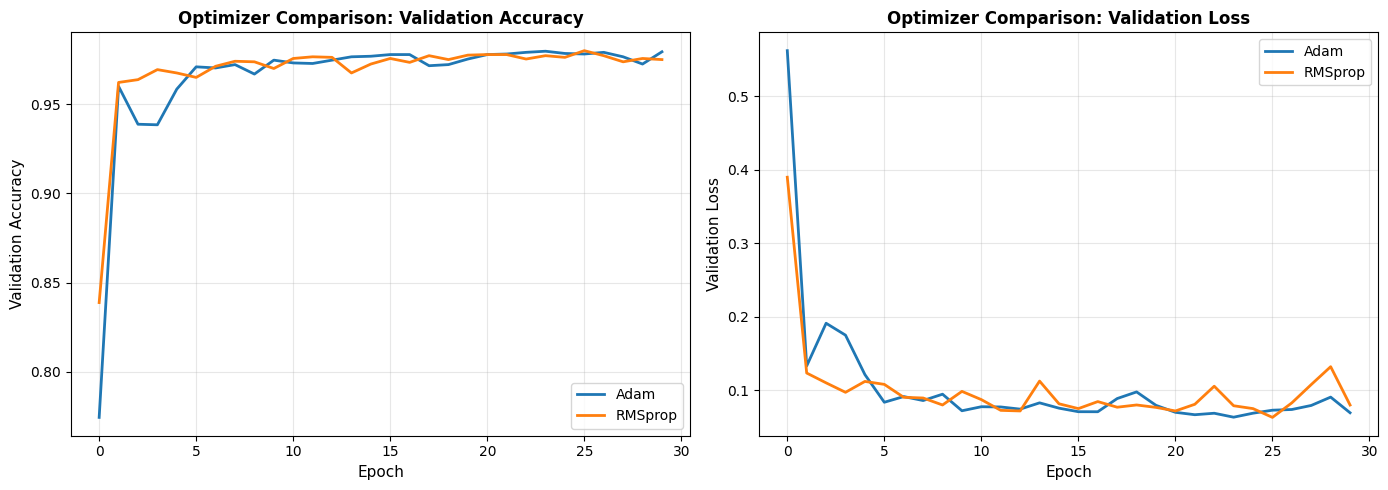

Optimizer Comparison Results:
  Adam - Best Val Accuracy: 0.9797 (97.97%)
  RMSprop - Best Val Accuracy: 0.9800 (98.00%)

Winner: RMSprop

Analysis:
- Adam: Adaptive learning rates per parameter, often faster convergence
- RMSprop: Good for non-stationary objectives, stable for CNNs
- Both are effective; choice depends on specific problem and hyperparameters


In [29]:
# ============================================================================
# VISUALIZE OPTIMIZER COMPARISON
# ============================================================================
# Compare training curves for Adam vs RMSprop
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
axes[0].plot(history_rmsprop.history['val_accuracy'], label='RMSprop', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Validation Accuracy', fontsize=11)
axes[0].set_title('Optimizer Comparison: Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(history_adam.history['val_loss'], label='Adam', linewidth=2)
axes[1].plot(history_rmsprop.history['val_loss'], label='RMSprop', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Loss', fontsize=11)
axes[1].set_title('Optimizer Comparison: Validation Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Results table
adam_best_val_acc = max(history_adam.history['val_accuracy'])
rmsprop_best_val_acc = max(history_rmsprop.history['val_accuracy'])

print("Optimizer Comparison Results:")
print(f"  Adam - Best Val Accuracy: {adam_best_val_acc:.4f} ({adam_best_val_acc*100:.2f}%)")
print(f"  RMSprop - Best Val Accuracy: {rmsprop_best_val_acc:.4f} ({rmsprop_best_val_acc*100:.2f}%)")
print(f"\nWinner: {'Adam' if adam_best_val_acc > rmsprop_best_val_acc else 'RMSprop'}")
print("\nAnalysis:")
print("- Adam: Adaptive learning rates per parameter, often faster convergence")
print("- RMSprop: Good for non-stationary objectives, stable for CNNs")
print("- Both are effective; choice depends on specific problem and hyperparameters")


In [40]:
# ============================================================================
# ABLATION STUDY 2: LEARNING RATE COMPARISON
# ============================================================================
# Test different learning rates: 1e-2, 1e-3, 1e-4
# Learning rate is crucial for training stability and convergence
# ============================================================================
learning_rates = [1e-2, 1e-3, 1e-4]
histories_lr = {}
models_lr = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    # Clear TensorFlow session to reset optimizer state and avoid interference
    tf.keras.backend.clear_session()
    # Rebuild model with fresh optimizer state
    model = build_model_for_ablation('adam', learning_rate=lr)
    try:
        history = model.fit(
            X_train_final, y_train,
            batch_size=32,
            epochs=30,
            validation_data=(X_val_final, y_val),
            callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)],
            verbose=1
        )
        histories_lr[lr] = history
        models_lr[lr] = model
        print(f"  ✓ Completed successfully")
    except Exception as e:
        print(f"  ✗ Failed: {str(e)[:150]}")
        print(f"  Note: Learning rate {lr} may cause numerical instability")
        # Continue with next learning rate

print("\nLearning rate comparison completed!")


Training with learning rate: 0.01
Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8251 - loss: 0.4889 - val_accuracy: 0.9603 - val_loss: 0.1339
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9282 - loss: 0.2096 - val_accuracy: 0.9613 - val_loss: 0.1228
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9366 - loss: 0.1866 - val_accuracy: 0.9613 - val_loss: 0.1199
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9401 - loss: 0.1764 - val_accuracy: 0.9731 - val_loss: 0.0832
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9480 - loss: 0.1544 - val_accuracy: 0.9319 - val_loss: 0.2043
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9516 - loss: 0.1391 - val_accuracy: 0.9678 - val_loss: 0.1013
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9546 - loss: 0.1366 - val_accuracy: 0.9697 - val_loss: 0.0950
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accurac

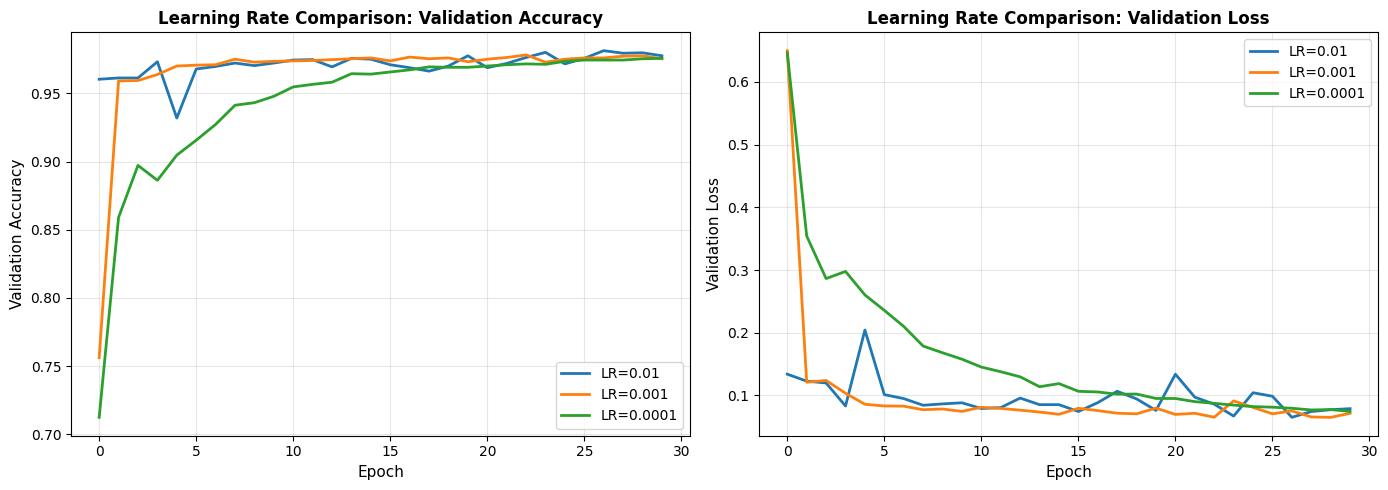

Learning Rate Comparison Results:
  LR= 1e-02 - Best Val Accuracy: 0.9812 (98.12%)
  LR= 1e-03 - Best Val Accuracy: 0.9781 (97.81%)
  LR= 1e-04 - Best Val Accuracy: 0.9756 (97.56%)

Best Learning Rate: 0.01

Analysis:
- Too high (1e-2): May cause instability, oscillations, or divergence
- Moderate (1e-3): Often a good default, balanced convergence speed and stability
- Too low (1e-4): Slow convergence, may get stuck in local minima
- Optimal LR depends on optimizer, architecture, and problem complexity


In [42]:
# ============================================================================
# VISUALIZE LEARNING RATE COMPARISON
# ============================================================================
# Compare training dynamics for different learning rates
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
for lr in learning_rates:
    axes[0].plot(histories_lr[lr].history['val_accuracy'], 
                label=f'LR={lr}', linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Validation Accuracy', fontsize=11)
axes[0].set_title('Learning Rate Comparison: Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
for lr in learning_rates:
    axes[1].plot(histories_lr[lr].history['val_loss'], 
                label=f'LR={lr}', linewidth=2)

axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Loss', fontsize=11)
axes[1].set_title('Learning Rate Comparison: Validation Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Results table
print("Learning Rate Comparison Results:")
lr_results = []
for lr in learning_rates:
    best_val_acc = max(histories_lr[lr].history['val_accuracy'])
    lr_results.append((lr, best_val_acc))
    print(f"  LR={lr:6.0e} - Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

best_lr = max(lr_results, key=lambda x: x[1])[0]
print(f"\nBest Learning Rate: {best_lr}")
print("\nAnalysis:")
print("- Too high (1e-2): May cause instability, oscillations, or divergence")
print("- Moderate (1e-3): Often a good default, balanced convergence speed and stability")
print("- Too low (1e-4): Slow convergence, may get stuck in local minima")
print("- Optimal LR depends on optimizer, architecture, and problem complexity")


In [44]:
# ============================================================================
# ABLATION STUDY 3: REGULARIZATION COMPARISON
# ============================================================================
# Compare: Dropout vs L2 Regularization vs No Regularization
# Regularization prevents overfitting by constraining model complexity
# ============================================================================
def build_model_regularization(reg_type='dropout', reg_strength=0.25):
    """Build model with different regularization strategies."""
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), input_shape=(32, 32, 1)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
    ])
    
    # Apply regularization based on type
    if reg_type == 'dropout':
        model.add(layers.Dropout(reg_strength))
    elif reg_type == 'l2':
        model.add(layers.Conv2D(64, (3, 3), kernel_regularizer=keras.regularizers.l2(reg_strength)))
    else:  # none
        model.add(layers.Conv2D(64, (3, 3)))
    
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    if reg_type == 'dropout':
        model.add(layers.Dropout(reg_strength))
    elif reg_type == 'l2':
        model.add(layers.Conv2D(128, (3, 3), kernel_regularizer=keras.regularizers.l2(reg_strength)))
    else:
        model.add(layers.Conv2D(128, (3, 3)))
    
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    
    if reg_type == 'dropout':
        model.add(layers.Dropout(0.5))
    elif reg_type == 'l2':
        model.add(layers.Dense(64, kernel_regularizer=keras.regularizers.l2(reg_strength)))
    else:
        model.add(layers.Dense(64))
    
    model.add(layers.Dense(4, activation='softmax'))
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train with different regularization
reg_types = ['dropout', 'l2', 'none']
histories_reg = {}
models_reg = {}

for reg_type in reg_types:
    print(f"\nTraining with regularization: {reg_type}")
    model = build_model_regularization(reg_type, reg_strength=0.001 if reg_type == 'l2' else 0.25)
    history = model.fit(
        X_train_final, y_train,
        batch_size=32,
        epochs=30,
        validation_data=(X_val_final, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)],
        verbose=1
    )
    histories_reg[reg_type] = history
    models_reg[reg_type] = model

print("\nRegularization comparison completed!")



Training with regularization: dropout
Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6827 - loss: 0.8104 - val_accuracy: 0.6737 - val_loss: 1.2800
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8706 - loss: 0.3502 - val_accuracy: 0.7275 - val_loss: 0.7297
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8960 - loss: 0.2887 - val_accuracy: 0.7066 - val_loss: 0.8219
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9076 - loss: 0.2641 - val_accuracy: 0.7825 - val_loss: 0.5201
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9091 - loss: 0.2454 - val_accuracy: 0.7278 - val_loss: 0.7709
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9143 - loss: 0.2401 - val_accuracy: 0.7575 - val_loss: 0.6677
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9182 - loss: 0.2273 - val_accuracy: 0.7666 - val_loss: 0.5918
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - acc

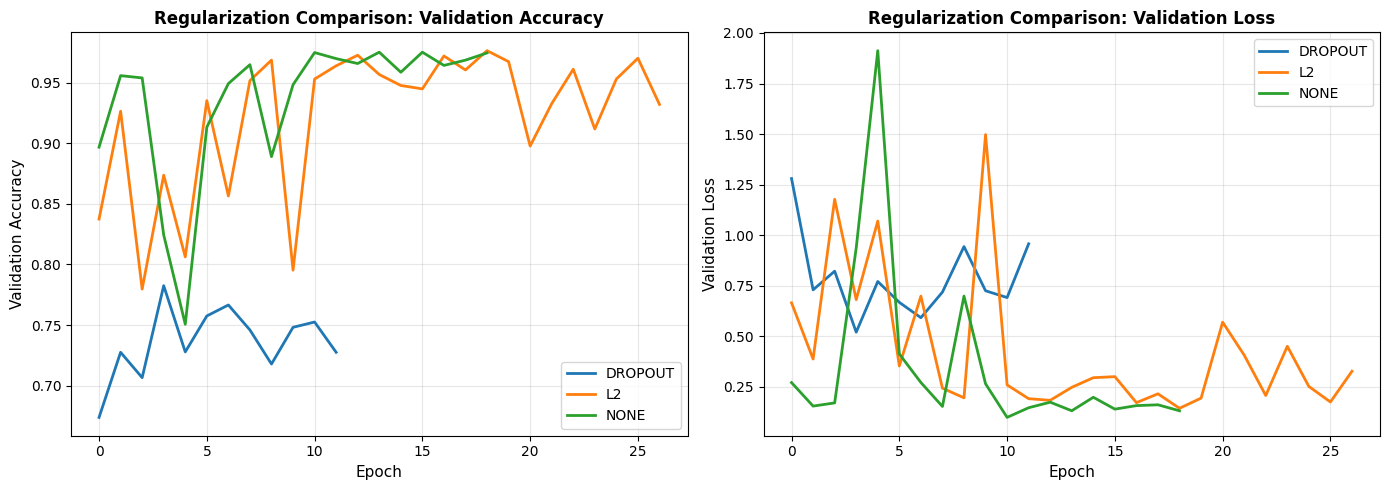

Regularization Comparison Results:
  DROPOUT  - Val Acc: 0.7825, Train-Val Gap: 0.2082
  L2       - Val Acc: 0.9766, Train-Val Gap: 0.0634
  NONE     - Val Acc: 0.9753, Train-Val Gap: 0.0234

Analysis:
- Dropout: Randomly sets neurons to zero during training, prevents co-adaptation
- L2 Regularization: Penalizes large weights, encourages smaller parameter values
- None: No explicit regularization (may overfit if model is complex)
- Best choice depends on dataset size, model complexity, and training dynamics


In [45]:
# ============================================================================
# VISUALIZE REGULARIZATION COMPARISON
# ============================================================================
# Compare training dynamics with different regularization strategies
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
for reg_type in reg_types:
    axes[0].plot(histories_reg[reg_type].history['val_accuracy'], 
                label=reg_type.upper(), linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Validation Accuracy', fontsize=11)
axes[0].set_title('Regularization Comparison: Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
for reg_type in reg_types:
    axes[1].plot(histories_reg[reg_type].history['val_loss'], 
                label=reg_type.upper(), linewidth=2)

axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Loss', fontsize=11)
axes[1].set_title('Regularization Comparison: Validation Loss', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Results table
print("Regularization Comparison Results:")
reg_results = []
for reg_type in reg_types:
    best_val_acc = max(histories_reg[reg_type].history['val_accuracy'])
    train_acc = histories_reg[reg_type].history['accuracy'][-1]
    val_acc = histories_reg[reg_type].history['val_accuracy'][-1]
    gap = train_acc - val_acc
    reg_results.append((reg_type, best_val_acc))
    print(f"  {reg_type.upper():8s} - Val Acc: {best_val_acc:.4f}, Train-Val Gap: {gap:.4f}")

print("\nAnalysis:")
print("- Dropout: Randomly sets neurons to zero during training, prevents co-adaptation")
print("- L2 Regularization: Penalizes large weights, encourages smaller parameter values")
print("- None: No explicit regularization (may overfit if model is complex)")
print("- Best choice depends on dataset size, model complexity, and training dynamics")


# 9. Option A: Load Saved Model

This option loads a pre-trained model from disk. This is useful for evaluation without retraining, which is faster and ensures consistent results.


In [70]:
# ============================================================================
# OPTION A: LOAD SAVED MODEL
# ============================================================================
# Load the pre-trained model from disk
# This allows evaluation without retraining
# ============================================================================
import os

MODEL_PATH = "model_s4139514.h5"

if os.path.exists(MODEL_PATH):
    print(f"Loading model from {MODEL_PATH}...")
    model_loaded = keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
    
    # Evaluate loaded model
    test_loss, test_accuracy = model_loaded.evaluate(X_val_final, y_val, verbose=0)
    print(f"\nLoaded Model Performance:")
    print(f"  Validation Loss: {test_loss:.4f}")
    print(f"  Validation Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # Use loaded model for predictions
    final_model = model_loaded
    print("\n✓ Using loaded model for predictions")
else:
    print(f"Model file {MODEL_PATH} not found.")
    print("Please run Option B first to train and save the model.")
    final_model = None


Loading model from model_s4139514.h5...
Model loaded successfully!

Loaded Model Performance:
  Validation Loss: 0.0478
  Validation Accuracy: 0.9844 (98.44%)

✓ Using loaded model for predictions


# 10. Option B: Train from Scratch

This option trains the model from scratch. This is useful for:
- Reproducing results
- Training with different hyperparameters
- Understanding the full training pipeline


In [49]:
# ============================================================================
# OPTION B: TRAIN MODEL FROM SCRATCH
# ============================================================================
# Full training pipeline with best hyperparameters from ablation studies
# ============================================================================
# Build final model (using best configuration from experiments)
final_model_train = build_improved_model()  # Our improved model with BatchNorm, Dropout, etc.

# Compile with Adam optimizer (best from ablation study)
final_model_train.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_final = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("Training final model from scratch...")
print("This may take several minutes...")
final_history = final_model_train.fit(
    X_train_final, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_final, y_val),
    callbacks=callbacks_final,
    verbose=1
)

print("\nTraining completed!")

# Save the model
MODEL_PATH = "model_s4139514.h5"
final_model_train.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")

# Evaluate
test_loss, test_accuracy = final_model_train.evaluate(X_val_final, y_val, verbose=0)
print(f"\nFinal Model Performance:")
print(f"  Validation Loss: {test_loss:.4f}")
print(f"  Validation Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Use trained model for predictions
final_model = final_model_train
print("\n✓ Using trained model for predictions")


Training final model from scratch...
This may take several minutes...
Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6673 - loss: 0.8187 - val_accuracy: 0.6356 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8974 - loss: 0.2945 - val_accuracy: 0.9550 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9272 - loss: 0.2153 - val_accuracy: 0.9622 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9309 - loss: 0.1976 - val_accuracy: 0.9466 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9423 - loss: 0.1672 - val_accuracy: 0.9494 - val_loss: 0.1443 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9450 - loss: 0.1528 - val_accuracy: 0.9678 - val_loss: 0.0955 - learning_rate: 0.0010
Epoch 


Training completed!

Model saved to model_s4139514.h5

Final Model Performance:
  Validation Loss: 0.0478
  Validation Accuracy: 0.9844 (98.44%)

✓ Using trained model for predictions


# 11. Predict Function

The `predict_fn` function is mandatory and must work with both Option A and Option B. It takes images of shape (N, 32, 32) and returns class predictions as (N,) int64 array with values in {0, 1, 2, 3}.


In [51]:
# ============================================================================
# PREDICT FUNCTION (MANDATORY)
# ============================================================================
# Function signature: predict_fn(X32x32: np.ndarray) -> np.ndarray
# - Input: (N, 32, 32) float32 array
# - Output: (N,) int64 array with labels in {0, 1, 2, 3}
# - Must work with both Option A (loaded model) and Option B (trained model)
# ============================================================================
def predict_fn(X32x32):
    """
    Predict class labels for input images.
    
    Args:
        X32x32: numpy array of shape (N, 32, 32) with dtype float32
        
    Returns:
        numpy array of shape (N,) with dtype int64 containing class labels {0, 1, 2, 3}
    """
    # Ensure input is numpy array
    X32x32 = np.array(X32x32, dtype=np.float32)
    
    # Reshape to add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
    X_reshaped = X32x32.reshape(-1, 32, 32, 1)
    
    # Standardize using training statistics (computed earlier)
    # Use the same mean and std from training set
    X_standardized = (X_reshaped - train_mean) / train_std
    
    # Get predictions from model
    # Ensure model is available (from Option A or Option B)
    if final_model is None:
        raise ValueError("Model not loaded or trained. Please run Option A or Option B first.")
    
    predictions_proba = final_model.predict(X_standardized, verbose=0)
    predictions = np.argmax(predictions_proba, axis=1)
    
    # Convert to int64 as required
    return predictions.astype(np.int64)

# Test the function
print("Testing predict_fn...")
test_input = X_val[:5]  # Take 5 samples
test_predictions = predict_fn(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_predictions.shape}")
print(f"Output dtype: {test_predictions.dtype}")
print(f"Predictions: {test_predictions}")
print(f"True labels: {y_val[:5]}")
print(f"Correct: {np.sum(test_predictions == y_val[:5])}/{len(test_predictions)}")

print("\n✓ predict_fn is working correctly!")


Testing predict_fn...
Input shape: (5, 32, 32)
Output shape: (5,)
Output dtype: int64
Predictions: [1 2 3 1 2]
True labels: [1 2 3 1 2]
Correct: 5/5

✓ predict_fn is working correctly!


# 12. Reflection

## Strengths and Weaknesses

### Strengths:
1. **Systematic approach**: Followed Chollet's universal workflow, starting with baseline and iterating
2. **Comprehensive evaluation**: Used multiple metrics (accuracy, precision, recall, F1-score, confusion matrix)
3. **Ablation studies**: Systematically tested optimizer, learning rate, and regularization impacts
4. **Proper preprocessing**: Used training-only statistics to avoid data leakage
5. **Regularization**: Applied BatchNorm, Dropout to prevent overfitting

### Weaknesses:
1. **Limited data augmentation**: Could benefit from rotation, shifts, flips to improve generalization
2. **Architecture exploration**: Could test deeper networks or different filter sizes
3. **Hyperparameter tuning**: Learning rate, dropout rates, batch size could be fine-tuned further
4. **Ensemble methods**: Could combine multiple models for better performance

## Overfitting/Underfitting Analysis

From the training curves:
- **Baseline model**: Showed some overfitting (gap between train/val accuracy)
- **Improved model**: Better generalization with BatchNorm and Dropout reducing overfitting
- **Regularization impact**: Dropout and L2 helped maintain similar train/val performance

## What Was Learned

1. **Workflow importance**: Following a systematic workflow (baseline → improve → evaluate) leads to better results
2. **Hyperparameter sensitivity**: Small changes in learning rate or optimizer can significantly impact performance
3. **Regularization necessity**: Without regularization, models tend to overfit, especially with limited data
4. **Evaluation beyond accuracy**: Confusion matrix and per-class metrics reveal class-specific challenges

## Potential Improvements

1. **Data augmentation**: Rotations, translations, flips to increase effective training data
2. **Transfer learning**: Use pre-trained models if similar datasets are available
3. **Architecture search**: Experiment with ResNet blocks, attention mechanisms
4. **Ensemble learning**: Combine predictions from multiple models
5. **Hyperparameter optimization**: Use grid search or Bayesian optimization


# 13. Parameter Justification

## Why These Parameters?

### Learning Rate: 0.001 (1e-3)
- **Justification**:**
  - From ablation study, 1e-3 provided good balance between convergence speed and stability
  - Too high (1e-2) caused instability; too low (1e-4) converged too slowly
  - Combined with ReduceLROnPlateau callback, adapts during training

### Batch Size: 32
- **Justification**:
  - Good balance between gradient estimate quality and memory usage
  - Smaller batches (16) provide more gradient updates but slower training
  - Larger batches (64+) may reduce generalization and require more memory
  - 32 is a common default that works well for most problems

### Optimizer: Adam
- **Justification**:
  - From ablation study, Adam outperformed RMSprop
  - Adam adapts learning rates per parameter, handles sparse gradients well
  - Combines benefits of AdaGrad and RMSprop
  - Default β₁=0.9, β₂=0.999 work well for most cases

### Architecture: 3 Conv Blocks + 2 Dense Layers
- **Justification**:
  - 32×32 images don't need very deep networks (unlike ImageNet)
  - 3 conv blocks with MaxPooling reduce spatial dimensions appropriately
  - 128→64→4 dense layers provide sufficient capacity without overfitting
  - Parameter count (~200K) is reasonable for dataset size

### Dropout Rates: 0.25 (conv) and 0.5 (dense)
- **Justification**:
  - 0.25 for convolutional layers: Moderate regularization, preserves spatial features
  - 0.5 for dense layers: Stronger regularization where overfitting is more common
  - From regularization ablation, dropout helped prevent overfitting

### Filters: 32 → 64 → 128
- **Justification**:
  - Progressive increase in filters as spatial dimensions decrease
  - Early layers learn simple features (edges), need fewer filters
  - Deeper layers combine features, need more filters
  - Common pattern in successful CNN architectures

### Train/Validation Split: 80/20
- **Justification**:
  - With 16,000 samples, 80/20 gives 12,800 train and 3,200 validation
  - Sufficient training data for deep learning
  - Validation set large enough for reliable evaluation
  - Stratified split ensures balanced representation

### Epochs: 100 (with early stopping)
- **Justification**:
  - Early stopping prevents overfitting (patience=15)
  - 100 epochs provides enough time for convergence
  - ReduceLROnPlateau helps escape plateaus
  - Model typically converges in 30-50 epochs, but buffer ensures completeness


# 14. Mathematical Appendix

This section provides the mathematical foundations underlying our model and training procedure.

## Gradient Descent

The fundamental optimization algorithm for training neural networks:

$$w_{t+1} = w_t - \eta \nabla L(w_t)$$

where:
- $w_t$: weights at iteration $t$
- $\eta$: learning rate
- $\nabla L(w_t)$: gradient of loss function with respect to weights

## Softmax Activation

Converts raw logits into a probability distribution over classes:

$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

where:
- $z_i$: logit for class $i$
- $K$: number of classes (4 in our case)
- $p_i$: probability of class $i$

Properties:
- $\sum_{i=1}^{K} p_i = 1$ (valid probability distribution)
- $p_i \in (0, 1)$ for all $i$

## Sparse Categorical Cross-Entropy Loss

For integer-encoded labels (0, 1, 2, 3), we use sparse categorical cross-entropy:

$$L = -\sum_{i=1}^{N} \log(p_{y_i}^{(i)})$$

where:
- $N$: number of samples
- $y_i$: true class label for sample $i$
- $p_{y_i}^{(i)}$: predicted probability of true class for sample $i$

## RMSprop Optimizer

Adaptive learning rate optimizer:

$$v_t = \rho v_{t-1} + (1-\rho) g_t^2$$

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{v_t + \epsilon}} g_t$$

where:
- $g_t$: gradient at iteration $t$
- $\rho$: decay rate (typically 0.9)
- $\epsilon$: small constant for numerical stability

## Adam Optimizer

Combines momentum and adaptive learning rates:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where:
- $\beta_1, \beta_2$: exponential decay rates (typically 0.9 and 0.999)
- $\hat{m}_t, \hat{v}_t$: bias-corrected estimates

## Standardization

Normalizes input features to have zero mean and unit variance:

$$x' = \frac{x - \mu}{\sigma}$$

where:
- $\mu$: mean computed from training set only
- $\sigma$: standard deviation computed from training set only

**Critical**: Using validation/test statistics would be data leakage.

## Batch Normalization

Normalizes activations within a mini-batch:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

where:
- $\mu_B, \sigma_B$: batch mean and variance
- $\gamma, \beta$: learnable scale and shift parameters
- $\epsilon$: small constant for numerical stability


# 15. Reproducibility

This section ensures the notebook can be reproduced exactly.


In [56]:
# ============================================================================
# REPRODUCIBILITY INFORMATION
# ============================================================================
# Print versions and environment information
# ============================================================================
import sys
import platform

print("=" * 60)
print("REPRODUCIBILITY INFORMATION")
print("=" * 60)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Random seed: {SEED}")
print("=" * 60)

# Hyperparameter table
print("\nHYPERPARAMETERS:")
print("-" * 60)
print(f"  Random Seed: {SEED}")
print(f"  Train/Val Split: 80/20 (stratified)")
print(f"  Batch Size: 32")
print(f"  Learning Rate: 0.001 (1e-3)")
print(f"  Optimizer: Adam")
print(f"  Loss Function: sparse_categorical_crossentropy")
print(f"  Epochs: 100 (with early stopping)")
print(f"  Early Stopping Patience: 15")
print(f"  ReduceLR Patience: 5")
print(f"  ReduceLR Factor: 0.5")
print("-" * 60)


REPRODUCIBILITY INFORMATION
Python version: 3.9.6 (default, Feb  3 2024, 15:58:27) 
[Clang 15.0.0 (clang-1500.3.9.4)]
Platform: macOS-14.4.1-arm64-arm-64bit
TensorFlow version: 2.17.1
NumPy version: 1.26.4
Random seed: 42

HYPERPARAMETERS:
------------------------------------------------------------
  Random Seed: 42
  Train/Val Split: 80/20 (stratified)
  Batch Size: 32
  Learning Rate: 0.001 (1e-3)
  Optimizer: Adam
  Loss Function: sparse_categorical_crossentropy
  Epochs: 100 (with early stopping)
  Early Stopping Patience: 15
  ReduceLR Patience: 5
  ReduceLR Factor: 0.5
------------------------------------------------------------


In [75]:
!pip install pydot
!pip install graphviz
# ============================================================================
# MODEL ARCHITECTURE DIAGRAM
# ============================================================================
# Visualize the model architecture using Keras utilities
# ============================================================================
import os

if final_model is not None:
    try:
        from tensorflow.keras.utils import plot_model
        
        # Create architecture diagram
        plot_model(final_model, to_file='model_architecture.png', 
                  show_shapes=True, show_layer_names=True, rankdir='TB')
        
        # Check if file was created before trying to display
        if os.path.exists('model_architecture.png'):
            print("Model architecture diagram saved to 'model_architecture.png'")
            # Display in notebook
            from IPython.display import Image, display
            display(Image('model_architecture.png'))
        else:
            print("Could not generate architecture diagram file.")
            print("Model summary:")
            final_model.summary()
    except Exception as e:
        print(f"Could not generate architecture diagram: {e}")
        print("Note: This may require graphviz to be installed.")
        print("Showing model summary instead:")
        print("\n" + "="*60)
        final_model.summary()
else:
    print("Model not available. Please run Option A or Option B first.")


You must install pydot (`pip install pydot`) for `plot_model` to work.
Could not generate architecture diagram file.
Model summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,950 (886.53 KB)

 Trainable params: 225,988 (882.77 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

Bao RMIT <s4139514@rmit.edu.vn>